# Preprocessing Pipeline
**COEN 330 - Applied Machine Learning**  
Builds the target, splits the data, fits the preprocessing pipeline, and saves the encoded arrays.  
Outputs: encoded train/test arrays + a saved `preprocessor.pkl`.

## Setup

In [3]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / 'src'))   # make src/ importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import preprocessing
from preprocessing import (
    load_and_create_target, split_data,
    fit_and_save_preprocessor, transform, get_feature_names,
)
from utils import DATA_RAW, DATASET_FILE, DATA_PROCESSED

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 1. Load Data & Create Target

`is_risky = 1 - loan_status` (risky = rejected applicant, used as a **proxy** for credit risk).

In [4]:
df = load_and_create_target(DATA_RAW / DATASET_FILE)
print(f'Shape: {df.shape}')

# Class balance — NOTE: risky (=1) is the MAJORITY class here (~78%).
balance = df['is_risky'].value_counts(normalize=True).round(3)
print('is_risky balance:')
print(balance)

Shape: (45000, 15)
is_risky balance:
is_risky
1    0.778
0    0.222
Name: proportion, dtype: float64


## 2. Cleaning Decisions

The pipeline caps `person_age` at 80 and log-transforms `person_income`. The cells below only
*document the justification* on the raw data but the actual transforms run inside `preprocessor`.

person_age - max: 144.0, rows > 80: 9  (capped to 80)
person_income - raw skew: 34.14  ->  after log1p: 0.22


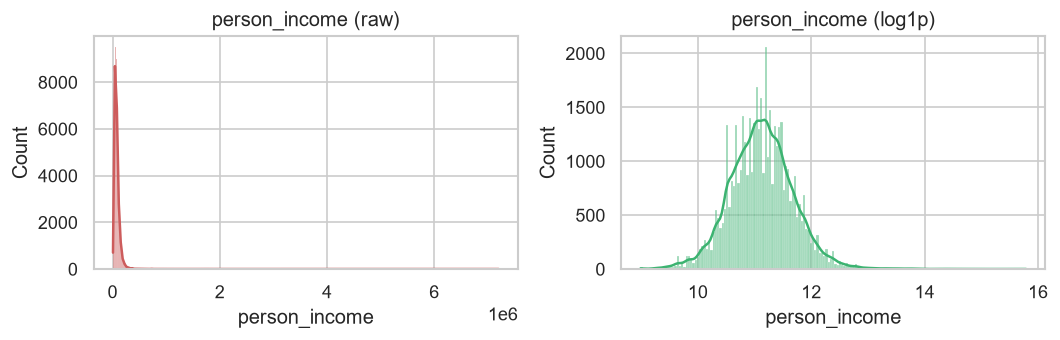

In [10]:
print(f'person_age - max: {df["person_age"].max()}, rows > 80: {(df["person_age"] > 80).sum()}  (capped to 80)')
print(f'person_income - raw skew: {df["person_income"].skew():.2f}  ->  after log1p: {np.log1p(df["person_income"]).skew():.2f}')

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
sns.histplot(df['person_income'], kde=True, ax=ax[0], color='indianred')
ax[0].set_title('person_income (raw)')
sns.histplot(np.log1p(df['person_income']), kde=True, ax=ax[1], color='mediumseagreen')
ax[1].set_title('person_income (log1p)')
plt.tight_layout(); plt.show()

## 3. Train / Test Split (80/20)

Stratified on `is_risky`.   
**k-fold Cross-Validation with k=5**: 5-fold StratifiedKFold runs inside the train set during tuning. Test set is only used during the final evaluation preventing data leakage.

In [11]:
X_train, X_test, y_train, y_test = split_data(df)

for name, y in [('Train', y_train), ('Test', y_test)]:
    print(f'{name:5s}: n={len(y):6,}  |  is_risky=1: {y.mean()*100:.1f}%')

Train: n=36,000  |  is_risky=1: 77.8%
Test : n= 9,000  |  is_risky=1: 77.8%


## 4. Encoding & Scaling

| Feature group | Columns | Strategy |
|---|---|---|
| Numerical | 8 columns | cap age + log income, then StandardScaler (fit on train only) |
| Ordinal | `person_education` | OrdinalEncoder (High School -> Doctorate = 0-4) |
| Nominal | gender, home_ownership, loan_intent, prev_defaults | OneHotEncoder (`handle_unknown='ignore'`) |

In [7]:
preprocessor = fit_and_save_preprocessor(X_train)   # saves to models/preprocessor.pkl

X_train_enc = transform(preprocessor, X_train)
X_test_enc  = transform(preprocessor, X_test)

feature_names = get_feature_names(preprocessor)

print(f'Encoded shape — Train: {X_train_enc.shape}, Test: {X_test_enc.shape}')
print(f'Feature names ({len(feature_names)}): {feature_names}')

Preprocessor saved to D:\Concordia Courses\Summer 2026\COEN 330\COEN 330 Project\COEN330-Machine-Learning-Project\models\preprocessor.pkl
Encoded shape — Train: (36000, 23), Test: (9000, 23)
Feature names (23): ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'person_education', 'person_gender_female', 'person_gender_male', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'previous_loan_defaults_on_file_No', 'previous_loan_defaults_on_file_Yes']


## 5. Leakage Check

Confirm neither `loan_status` (source of target) nor `is_risky` leaked into the features.

In [8]:
assert 'loan_status' not in feature_names, 'DATA LEAKAGE: loan_status in features!'
assert 'is_risky' not in feature_names, 'DATA LEAKAGE: is_risky in features!'
print('Leakage check passed.')

Leakage check passed.


## 6. Save Processed Arrays

In [9]:
import json

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
np.save(DATA_PROCESSED / 'X_train.npy', X_train_enc)
np.save(DATA_PROCESSED / 'X_test.npy',  X_test_enc)
y_train.to_csv(DATA_PROCESSED / 'y_train.csv', index=False)
y_test.to_csv(DATA_PROCESSED / 'y_test.csv',   index=False)
with open(DATA_PROCESSED / 'feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print('Processed data saved to', DATA_PROCESSED)

Processed data saved to D:\Concordia Courses\Summer 2026\COEN 330\COEN 330 Project\COEN330-Machine-Learning-Project\data\processed


## 7. Preprocessing Summary

| Step | Decision | Justification |
|---|---|---|
| Target | `is_risky = 1 - loan_status` | Risky = rejected applicant (proxy for credit risk) |
| Class balance | risky = ~78% (majority) | Affects metric choice; need to use threshold tuning for imbalanced class |
| Outlier Handling | cap `person_age` at 80 | >80 is implausible age for giving out loans (average life expectancy in Canada = 82.5 years) |
| Skewness | log1p on `person_income` | Heavy right skew on raw income |
| Dropped Column | `loan_status` | Cource of target: therefore, if used, it would introduce data leakage |
| Encoding | Ordinal for `person_education` | Natural ordering: HS < ... < Doctorate |
| Encoding | OneHotEncoder for other categoricals | No natural ordering; `handle_unknown='ignore'` for demo robustness |
| Scaling | StandardScaler on numerical | Required for distance/margin-based models (SVM, k-NN) |
| Split | 80/20 stratified; Cross-Validation inside train set | Test set to be only used for the final evaluation |